# Step 1 - Liberaries Install

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn pillow ipywidgets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 57.3 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.20.0
GPU Available: True


# Dataset import

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [4]:
import os

print("Dataset Location:")
print(path)

print("\nFiles and Folders:")
print(os.listdir(path))

Dataset Location:
/kaggle/input/chest-xray-pneumonia

Files and Folders:
['chest_xray']


In [5]:
dataset_path = os.path.join(path, "chest_xray")

print("Actual Dataset Path:")
print(dataset_path)

print("\nDataset Folders:")
print(os.listdir(dataset_path))

Actual Dataset Path:
/kaggle/input/chest-xray-pneumonia/chest_xray

Dataset Folders:
['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [6]:
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")

print("Train Path      :", train_path)
print("Validation Path :", val_path)
print("Test Path       :", test_path)

Train Path      : /kaggle/input/chest-xray-pneumonia/chest_xray/train
Validation Path : /kaggle/input/chest-xray-pneumonia/chest_xray/val
Test Path       : /kaggle/input/chest-xray-pneumonia/chest_xray/test


In [7]:
print("Classes in Training Dataset:")

classes = os.listdir(train_path)

for i, class_name in enumerate(classes):
    print(i, "→", class_name)

Classes in Training Dataset:
0 → PNEUMONIA
1 → NORMAL


In [8]:
def count_images(folder):

    return len([
        file for file in os.listdir(folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])


for class_name in classes:

    class_folder = os.path.join(train_path, class_name)

    print(
        f"{class_name}: "
        f"{count_images(class_folder)} images"
    )

PNEUMONIA: 3875 images
NORMAL: 1341 images


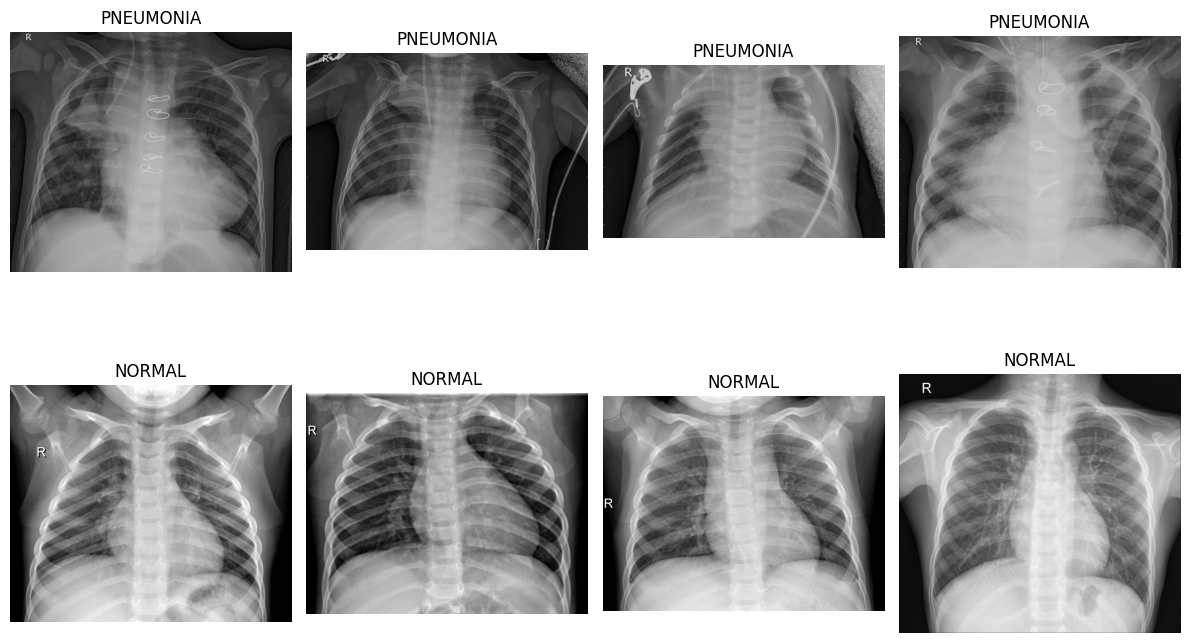

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(12, 8))

plot_number = 1

for class_name in classes:

    class_folder = os.path.join(train_path, class_name)

    image_files = [
        file for file in os.listdir(class_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    selected_images = random.sample(
        image_files,
        min(4, len(image_files))
    )

    for image_file in selected_images:

        image_path = os.path.join(
            class_folder,
            image_file
        )

        img = Image.open(image_path)

        plt.subplot(2, 4, plot_number)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

        plot_number += 1

plt.tight_layout()
plt.show()

In [10]:
sample_class = classes[0]

sample_folder = os.path.join(
    train_path,
    sample_class
)

sample_file = [
    file for file in os.listdir(sample_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
][0]

sample_image = Image.open(
    os.path.join(sample_folder, sample_file)
)

print("Image Size:", sample_image.size)
print("Image Mode:", sample_image.mode)

Image Size: (1024, 712)
Image Mode: L


#Image Preprocessing

In [11]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)

Image Size: (150, 150)
Batch Size: 32


In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Pixel normalization configured successfully!")

Pixel normalization configured successfully!


In [13]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 5216 images belonging to 2 classes.


#

In [14]:
val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 16 images belonging to 2 classes.


In [15]:
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [16]:
print("Class Mapping:")
print(train_data.class_indices)

Class Mapping:
{'NORMAL': 0, 'PNEUMONIA': 1}


In [17]:
images, labels = next(train_data)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)
print("Pixel Minimum     :", images.min())
print("Pixel Maximum     :", images.max())

Image Batch Shape : (32, 150, 150, 3)
Label Batch Shape : (32,)
Pixel Minimum     : 0.0
Pixel Maximum     : 1.0


# Data Augmentation

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [19]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 5216 images belonging to 2 classes.


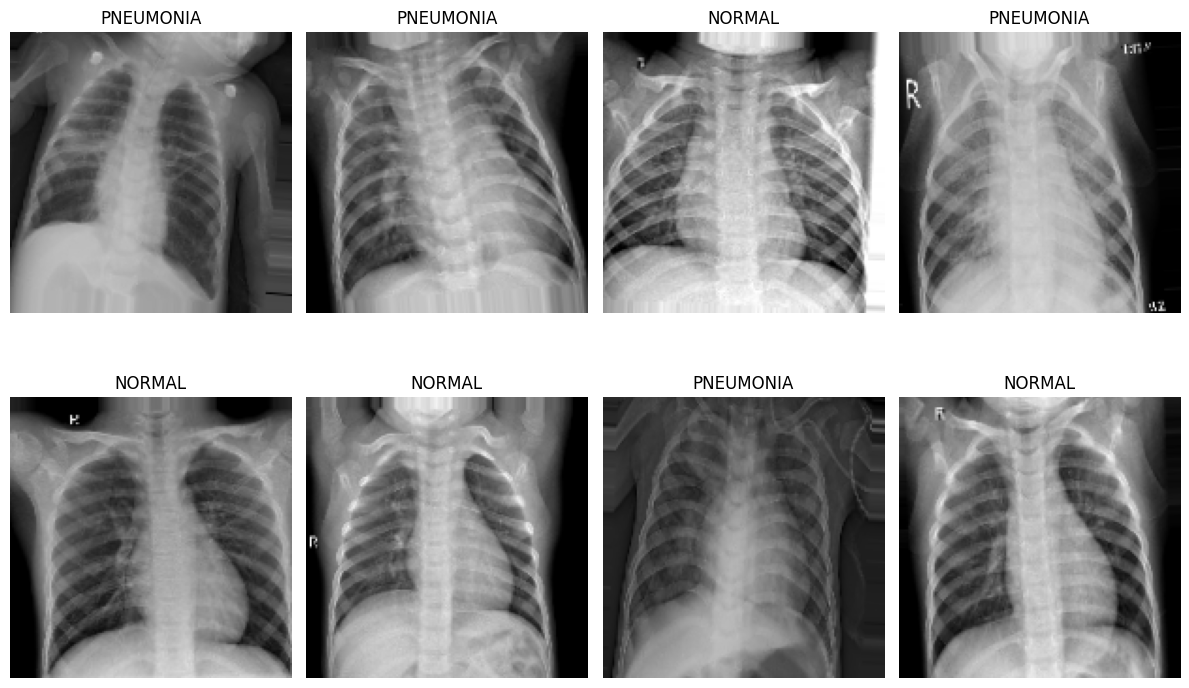

In [20]:
augmented_images, augmented_labels = next(train_data)

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented_images[i])
    plt.title(
        "PNEUMONIA" if augmented_labels[i] == 1 else "NORMAL"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

#Build CNN Model

In [21]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(150, 150, 3)),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        128, (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        256, (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])



In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

# Compile CNN

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Improved CNN model compiled successfully!")

Improved CNN model compiled successfully!


In [24]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


# CNN Training

In [25]:
EPOCHS = 20

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 565ms/step - accuracy: 0.8616 - loss: 0.3181 - precision: 0.9666 - recall: 0.8428 - val_accuracy: 0.5000 - val_loss: 2.3958 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 444ms/step - accuracy: 0.9045 - loss: 0.2156 - precision: 0.9793 - recall: 0.8903 - val_accuracy: 0.5000 - val_loss: 5.0282 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 444ms/step - accuracy: 0.9214 - loss: 0.1867 - precision: 0.9800 - recall: 0.9128 - val_accuracy: 0.5000 - val_loss: 4.5747 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 449ms/step - accuracy: 0.9323 - loss: 0.1706 - precision: 0.9796 - recall: 0.9283 - val_accuracy: 0.5625 - val_loss: 2.4730 - val_precision: 0.5333 - val_recall: 1.0000
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 449ms/step - accuracy: 0.9400 - loss: 0.1468 - precision: 0.9814 - recall: 0.9370 - val_accuracy: 0.625

# Accuracy & Loss Graphs

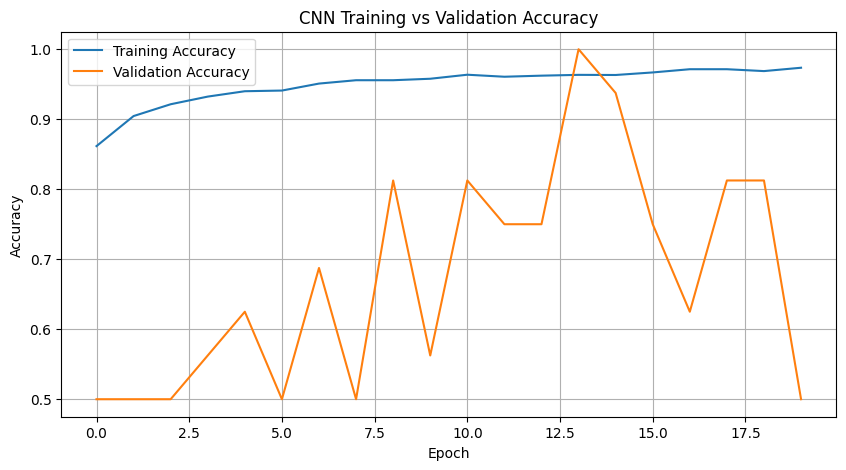

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

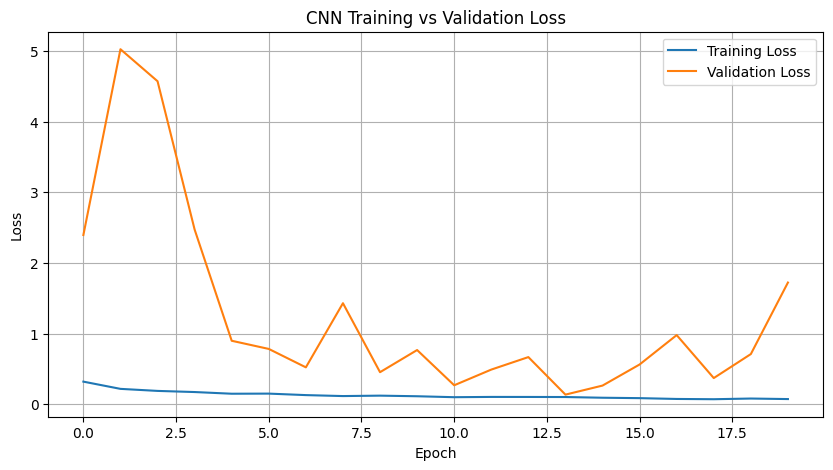

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
best_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

best_val_accuracy = max(
    history.history["val_accuracy"]
)

print("Best Epoch:", best_epoch)
print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy * 100:.2f}%"
)

Best Epoch: 14
Best Validation Accuracy: 100.00%


# Test Dataset Evaluation

In [29]:
# Evaluate the model on test data

test_results = model.evaluate(
    test_data,
    verbose=1,
    return_dict=True
)

print("\nTest Results")
print("-" * 40)

test_loss = test_results["loss"]
test_accuracy = test_results["accuracy"]
test_precision = test_results["precision"]
test_recall = test_results["recall"]

print("Test Loss      :", f"{test_loss:.4f}")
print("Test Accuracy  :", f"{test_accuracy * 100:.2f}%")
print("Test Precision :", f"{test_precision * 100:.2f}%")
print("Test Recall    :", f"{test_recall * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.6426 - loss: 0.9234 - precision: 0.9827 - recall: 0.4359

Test Results
----------------------------------------
Test Loss      : 0.9234
Test Accuracy  : 64.26%
Test Precision : 98.27%
Test Recall    : 43.59%


# Test Images Prediction

In [30]:
test_data.reset()

predicted_probabilities = model.predict(
    test_data,
    verbose=1
)

predicted_labels = (
    predicted_probabilities >= 0.5
).astype(int).ravel()

actual_labels = test_data.classes

print("Predictions generated successfully!")
print("Total Test Images:", len(actual_labels))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step
Predictions generated successfully!
Total Test Images: 624


# Confusion Matrix

In [ ]:
cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

# Classification Report

In [ ]:
report = classification_report(
    actual_labels,
    predicted_labels,
    target_names=[
        "NORMAL",
        "PNEUMONIA"
    ]
)

print(report)

# Single X- Ray Prediction

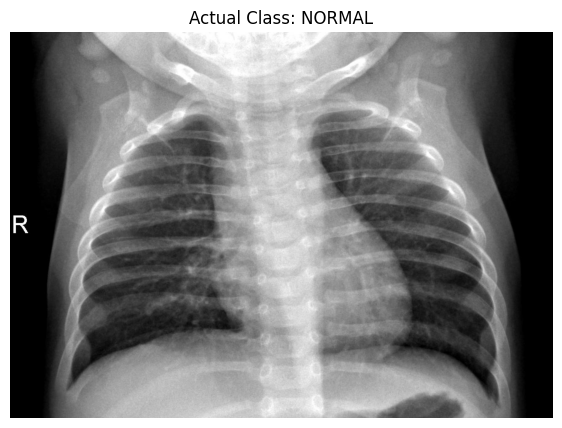

Image Path: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0346-0001.jpeg


In [33]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Test folders
normal_folder = os.path.join(test_path, "NORMAL")
pneumonia_folder = os.path.join(test_path, "PNEUMONIA")

# Randomly select one image
normal_images = [
    f for f in os.listdir(normal_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

pneumonia_images = [
    f for f in os.listdir(pneumonia_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Select one random image
selected_file = random.choice(normal_images)
selected_path = os.path.join(normal_folder, selected_file)

# Display
selected_image = Image.open(selected_path)

plt.figure(figsize=(7, 7))
plt.imshow(selected_image, cmap="gray")
plt.title("Actual Class: NORMAL")
plt.axis("off")
plt.show()

print("Image Path:", selected_path)

In [34]:
# Prepare image
img = tf.keras.utils.load_img(
    selected_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    predicted_class = "PNEUMONIA"
    probability = prediction
else:
    predicted_class = "NORMAL"
    probability = 1 - prediction

print("=" * 40)
print("CNN PREDICTION")
print("=" * 40)
print("Actual Class    :", "NORMAL")
print("Predicted Class :", predicted_class)
print("Probability     :", f"{probability * 100:.2f}%")
print("=" * 40)

CNN PREDICTION
Actual Class    : NORMAL
Predicted Class : NORMAL
Probability     : 99.97%


# Dashboard

In [35]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random
from PIL import Image

# -----------------------------
# Get image files
# -----------------------------

normal_files = [
    f for f in os.listdir(normal_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

pneumonia_files = [
    f for f in os.listdir(pneumonia_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]


# -----------------------------
# Dashboard Title
# -----------------------------

title = widgets.HTML(
    """
    <div style="text-align:center; padding:15px;">
        <h1>🩻 Chest X-Ray CNN Dashboard</h1>
        <h3>Normal vs Pneumonia Classification</h3>
    </div>
    """
)


# -----------------------------
# Class Dropdown
# -----------------------------

class_dropdown = widgets.Dropdown(
    options=["NORMAL", "PNEUMONIA"],
    value="NORMAL",
    description="Class:"
)


# -----------------------------
# Image Dropdown
# -----------------------------

image_dropdown = widgets.Dropdown(
    description="X-Ray:"
)


def update_images(change=None):

    selected_class = class_dropdown.value

    if selected_class == "NORMAL":

        image_dropdown.options = normal_files

    else:

        image_dropdown.options = pneumonia_files


update_images()

class_dropdown.observe(
    update_images,
    names="value"
)


# -----------------------------
# Predict Button
# -----------------------------

predict_button = widgets.Button(
    description="🔍 Predict",
    button_style="success",
    layout=widgets.Layout(
        width="180px",
        height="40px"
    )
)


# -----------------------------
# Output Area
# -----------------------------

output = widgets.Output()


# -----------------------------
# Prediction Function
# -----------------------------

def predict_selected_image(button):

    with output:

        clear_output(wait=True)

        selected_class = class_dropdown.value
        selected_file = image_dropdown.value

        if selected_class == "NORMAL":

            image_path = os.path.join(
                normal_folder,
                selected_file
            )

        else:

            image_path = os.path.join(
                pneumonia_folder,
                selected_file
            )


        # Load image
        img = tf.keras.utils.load_img(
            image_path,
            target_size=IMG_SIZE
        )


        # Convert image to array
        img_array = tf.keras.utils.img_to_array(img)

        img_array = img_array / 255.0

        img_array = np.expand_dims(
            img_array,
            axis=0
        )


        # CNN Prediction
        prediction = model.predict(
            img_array,
            verbose=0
        )[0][0]


        # Convert probability to class
        if prediction >= 0.5:

            predicted_class = "PNEUMONIA"
            confidence = prediction

        else:

            predicted_class = "NORMAL"
            confidence = 1 - prediction


        # Display image
        plt.figure(figsize=(7, 7))

        plt.imshow(img)

        plt.title(
            f"Actual: {selected_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Probability: {confidence * 100:.2f}%"
        )

        plt.axis("off")

        plt.show()


        # Result
        print("=" * 50)
        print("             CNN PREDICTION")
        print("=" * 50)

        print(f"Actual Class    : {selected_class}")
        print(f"Predicted Class : {predicted_class}")
        print(
            f"Confidence      : "
            f"{confidence * 100:.2f}%"
        )

        print("=" * 50)


# Connect button
predict_button.on_click(
    predict_selected_image
)


# -----------------------------
# Display Dashboard
# -----------------------------

display(
    title,
    class_dropdown,
    image_dropdown,
    predict_button,
    output
)

HTML(value='\n    <div style="text-align:center; padding:15px;">\n        <h1>🩻 Chest X-Ray CNN Dashboard</h1>…

Dropdown(description='Class:', options=('NORMAL', 'PNEUMONIA'), value='NORMAL')

Dropdown(description='X-Ray:', options=('NORMAL2-IM-0336-0001.jpeg', 'IM-0101-0001.jpeg', 'NORMAL2-IM-0337-000…

Button(button_style='success', description='🔍 Predict', layout=Layout(height='40px', width='180px'), style=But…

Output()